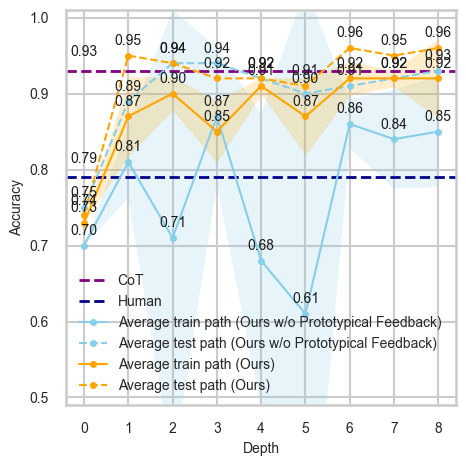

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 데이터 준비
depth = np.arange(9)

base_train_mean = [0.70, 0.81, 0.71, 0.87, 0.68, 0.61, 0.86, 0.84, 0.85]
base_train_std  = [0.000,0.048,0.300,0.091,0.193,0.429,0.032,0.065,0.073]

base_test_mean = [0.75, 0.89, 0.94, 0.94, 0.92, 0.90, 0.91, 0.92, 0.93]
base_test_std  = [0.000]*9

ours_train_mean = [0.73, 0.87, 0.90, 0.85, 0.91, 0.87, 0.92, 0.92, 0.92]
ours_train_std  = [0.000,0.052,0.022,0.041,0.011,0.051,0.022,0.011,0.052]

ours_test_mean = [0.74, 0.95, 0.94, 0.92, 0.92, 0.91, 0.96, 0.95, 0.96]
ours_test_std  = [0.000]*9

# 스타일 설정
sns.set(style="whitegrid", context="talk", palette="colorblind")

plt.figure(figsize=(5,5))

# 각 curve + shade
def plot_with_shade(x, mean, std, label, color, marker, dash=False):
    if dash:
        plt.plot(x, mean, label=label, color=color, marker=marker, linewidth=1.5, markersize=4, linestyle='--')
    else:
        plt.plot(x, mean, label=label, color=color, marker=marker, linewidth=1.5, markersize=4)
    plt.fill_between(
        x,
        np.array(mean) - np.array(std),
        np.array(mean) + np.array(std),
        color=color, alpha=0.2, linewidth=0, edgecolor=None
    )
    # 각 마커 위에 실제 값 표시
    for xi, yi in zip(x, mean):
        plt.text(xi, yi + 0.010, f"{yi:.2f}", ha='center', va='bottom', fontsize=10, color='k')

# 색상 팔레트 가져오기
palette = sns.color_palette("Set3", 6)

plt.axhline(y=0.93, color="purple", linestyle='--', linewidth=2, label='CoT')
plt.text(0, 0.93 + 0.015, f"{0.93:.2f}", ha='center', va='bottom', fontsize=10, color="k")
plt.axhline(y=0.79, color="darkblue", linestyle='--', linewidth=2, label='Human')
plt.text(0, 0.79 + 0.015, f"{0.79:.2f}", ha='center', va='bottom', fontsize=10, color="k")
plot_with_shade(depth, base_train_mean, base_train_std, "Average train path (Ours w/o Prototypical Feedback)", "skyblue", "o")
plot_with_shade(depth, base_test_mean, base_test_std, "Average test path (Ours w/o Prototypical Feedback)", "skyblue", "o", dash=True)
plot_with_shade(depth, ours_train_mean, ours_train_std, "Average train path (Ours)", "orange", "o")
plot_with_shade(depth, ours_test_mean, ours_test_std, "Average test path (Ours)", "orange", "o", dash= True)
 
plt.ylim(0.49, 1.01)
plt.xticks(depth)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.xlabel("Depth", fontsize=10)
plt.ylabel("Accuracy", fontsize=10)
# plt.title("Reward by Depth", fontsize=16, weight="bold")

plt.legend(title="", loc="lower left", fontsize=10, frameon=False)
plt.tight_layout()
plt.savefig("depth_vs_accuracy.pdf", dpi=300)
plt.show()
